In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [113]:
# !pip install ucimlrepo

In [114]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)

{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [115]:
X

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [116]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB


In [117]:
X.isna().sum()

,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [118]:
X.Description.unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'lost',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], dtype=object)

In [119]:
X.Description = X.Description.fillna(X.Description.mode()[0])

/tmp/ipython-input-1979094001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.Description = X.Description.fillna(X.Description.mode()[0])


In [120]:
X.isna().sum()

,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [121]:
X.CustomerID.unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.])

In [122]:
X.CustomerID = X.CustomerID.fillna(X.CustomerID.median())

/tmp/ipython-input-2551842080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.CustomerID = X.CustomerID.fillna(X.CustomerID.median())


In [123]:
X.isna().sum()

,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


KNN as an imputer

In [124]:
data = pd.DataFrame({
    'Age': [25,30,np.nan,40,35,np.nan,28],
    'Salary': [50000, 60000, 55000, np.nan, 65000, 52000, np.nan],
    'Experience': [2,5,3,10,7,4,3]
})

In [125]:
data.isna().sum()

,0
Age,2
Salary,2
Experience,0


In [126]:
data

,Age,Salary,Experience
0,25.0,50000.0,2
1,30.0,60000.0,5
2,NaN,55000.0,3
3,40.0,NaN,10
4,35.0,65000.0,7
5,NaN,52000.0,4
6,28.0,NaN,3


In [127]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors= 5)
imputed_array = imputer.fit_transform(data)

In [128]:
imputed_data = pd.DataFrame(imputed_array, columns= data.columns)
imputed_data

,Age,Salary,Experience
0,25.0,50000.0,2.0
1,30.0,60000.0,5.0
2,31.6,55000.0,3.0
3,40.0,56400.0,10.0
4,35.0,65000.0,7.0
5,31.6,52000.0,4.0
6,28.0,56400.0,3.0


In [129]:
imputed_data.isna().sum()

,0
Age,0
Salary,0
Experience,0


In [130]:
# outlier >>  a data point that significantly deviates from other observations in a dataset.
# Outliers can arise due to measurement errors, natural variation, or rare events, and
# they can have a disproportionate impact on statistical analyses and machine learning models if not appropriately handled.

In [131]:
data = np.array([10,50,55,57,70,76,78,80,100,120])
data

array([ 10,  50,  55,  57,  70,  76,  78,  80, 100, 120])

In [132]:
Q1 = np.percentile(data, 25)
Q2 = np.percentile(data, 50)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q2: {Q2}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

Q1: 55.5
Q2: 73.0
Q3: 79.5
IQR: 24.0


In [133]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [134]:
print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)

Lower Bound:  19.5
Upper Bound:  115.5


In [135]:
outlier = []
for num in data:
  if num < lower_bound or num > upper_bound:
    outlier.append(num)

print(outlier)

[np.int64(10), np.int64(120)]


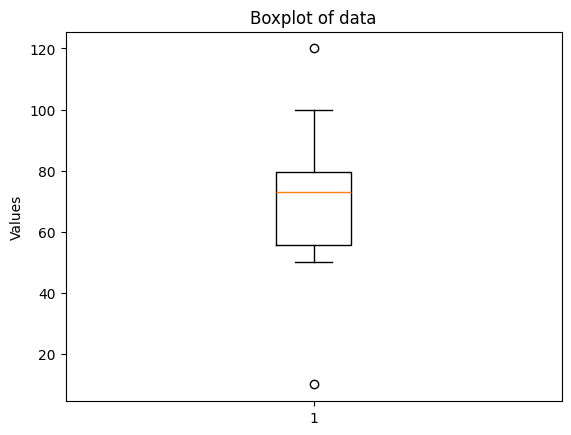

In [136]:
plt.figure()
plt.boxplot(data)
plt.title("Boxplot of data")
plt.ylabel("Values")
plt.show()

In [137]:
data = {
    'Customer': ['Riya', 'Meena', 'Tejas', 'Divya', 'Paras'],
    'Satisfaction': ['Low', 'High', 'Medium', 'Very High', 'Low']
}

df = pd.DataFrame(data)
df

,Customer,Satisfaction
0,Riya,Low
1,Meena,High
2,Tejas,Medium
3,Divya,Very High
4,Paras,Low


In [138]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df["Label_Encoded"] = label.fit_transform(df["Satisfaction"])

print(df)

  Customer Satisfaction  Label_Encoded
0     Riya          Low              1
1    Meena         High              0
2    Tejas       Medium              2
3    Divya    Very High              3
4    Paras          Low              1


In [139]:
data = {
    'Customer': ['Riya', 'Meena', 'Tejas', 'Divya', 'Paras'],
    'Gender': ['Female', 'Female', 'Male', 'Female', 'Male']
}

df = pd.DataFrame(data)
df

,Customer,Gender
0,Riya,Female
1,Meena,Female
2,Tejas,Male
3,Divya,Female
4,Paras,Male


In [140]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df["Label_Encoded"] = label.fit_transform(df["Gender"])

print(df)

  Customer  Gender  Label_Encoded
0     Riya  Female              0
1    Meena  Female              0
2    Tejas    Male              1
3    Divya  Female              0
4    Paras    Male              1


In [141]:
data = {
    'Customer': ['Riya', 'Meena', 'Tejas', 'Divya', 'Paras'],
    'Satisfaction': ['Low', 'High', 'Medium', 'Very High', 'Low']
}

df = pd.DataFrame(data)
df

,Customer,Satisfaction
0,Riya,Low
1,Meena,High
2,Tejas,Medium
3,Divya,Very High
4,Paras,Low


In [142]:
from sklearn.preprocessing import OrdinalEncoder

rank = [['Low', 'Medium', 'High', 'Very High']]
order = OrdinalEncoder(categories= rank)
df['Order_Encoded'] = order.fit_transform(df[['Satisfaction']]).astype(int)
print(df)

  Customer Satisfaction  Order_Encoded
0     Riya          Low              0
1    Meena         High              2
2    Tejas       Medium              1
3    Divya    Very High              3
4    Paras          Low              0


In [143]:
X = df['Satisfaction']
user_encoded = pd.get_dummies(X).astype(int)
user_encoded

,High,Low,Medium,Very High
0,0,1,0,0
1,1,0,0,0
2,0,0,1,0
3,0,0,0,1
4,0,1,0,0


In [144]:
data = {
    'Salary': [30000, 50000, 70000, 200000],
    'Experience': [2,5,7,10],
    'Age': [25, 30, 35, 60]
}

df = pd.DataFrame(data)
print("Original Data:\n")
print(df)

Original Data:

   Salary  Experience  Age
0   30000           2   25
1   50000           5   30
2   70000           7   35
3  200000          10   60


Task1: Find Maximum & Minimum of all the features

In [145]:
df['Salary'].min()

30000

In [146]:
df['Salary'].max()

200000

In [147]:
df['Age'].min()

25

In [148]:
df['Age'].max()

60

In [149]:
df['Experience'].min()

2

In [150]:
df['Experience'].max()

10

In [151]:
df.min()

,0
Salary,30000
Experience,2
Age,25


In [152]:
df.max()

,0
Salary,200000
Experience,10
Age,60


In [153]:
df.mean()

,0
Salary,87500.0
Experience,6.0
Age,37.5


In [154]:
from sklearn.preprocessing import MaxAbsScaler
maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df), columns= df.columns)
print(df_maxabs)

   Salary  Experience       Age
0    0.15         0.2  0.416667
1    0.25         0.5  0.500000
2    0.35         0.7  0.583333
3    1.00         1.0  1.000000


In [155]:
df_maxabs

,Salary,Experience,Age
0,0.15,0.2,0.416667
1,0.25,0.5,0.500000
2,0.35,0.7,0.583333
3,1.00,1.0,1.000000


In [156]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns= df.columns)
print(df_minmax)

     Salary  Experience       Age
0  0.000000       0.000  0.000000
1  0.117647       0.375  0.142857
2  0.235294       0.625  0.285714
3  1.000000       1.000  1.000000


In [157]:
from sklearn.preprocessing import Normalizer
l2_normalizer = Normalizer(norm= 'l2')
df_l2 = pd.DataFrame(l2_normalizer.fit_transform(df), columns= df.columns)

print("L2 Normalized Data: \n")
print(df_l2)

L2 Normalized Data: 

   Salary  Experience       Age
0     1.0    0.000067  0.000833
1     1.0    0.000100  0.000600
2     1.0    0.000100  0.000500
3     1.0    0.000050  0.000300


In [158]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df), columns= df.columns)
print(df_standard)

     Salary  Experience       Age
0 -0.865004   -1.371989 -0.928477
1 -0.564133   -0.342997 -0.557086
2 -0.263262    0.342997 -0.185695
3  1.692399    1.371989  1.671258


HW - Preprocessing or Feature Engineering

  1. Find Dataset from UCIML that having numerical and string missing values and handle it with KNNImputer.
  
  2. Find dataset from UCIML that having outliers. Find method to find outliers from dataset rather than IQR.

In [159]:
# Heart Disease dataset

from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [160]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [161]:
X.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [162]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors= 4)
imputer

KNNImputer(n_neighbors=4)

In [163]:
imputed_array = imputer.fit_transform(X)

In [164]:
imputed_df = pd.DataFrame(imputed_array, columns= X.columns)

In [165]:
imputed_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0


In [166]:
# Forest Fire dataset

from ucimlrepo import fetch_ucirepo

# fetch dataset
forest_fires = fetch_ucirepo(id=162)

# data (as pandas dataframes)
X = forest_fires.data.features
y = forest_fires.data.targets

# metadata
print(forest_fires.metadata)

# variable information
print(forest_fires.variables)

{'uci_id': 162, 'name': 'Forest Fires', 'repository_url': 'https://archive.ics.uci.edu/dataset/162/forest+fires', 'data_url': 'https://archive.ics.uci.edu/static/public/162/data.csv', 'abstract': 'This is a difficult regression task, where the aim is to predict the burned area of forest fires, in the northeast region of Portugal, by using meteorological and other data (see details at: http://www.dsi.uminho.pt/~pcortez/forestfires).', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 517, 'num_features': 12, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['area'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2007, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5D88D', 'creators': ['Paulo Cortez', 'Anbal Morais'], 'intro_paper': {'ID': 368, 'type': 'NATIVE', 'title': 'A data mining approach to predict forest fires using meteorological da

In [167]:
X

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [168]:
num_cols = [col for col in X.columns if X[col].dtypes != 'object']

In [169]:
from sklearn.ensemble import IsolationForest
detector = IsolationForest()
detector

IsolationForest()

In [170]:
y_pred = detector.fit_predict(X[num_cols])
y_pred

array([ 1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,
        1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1

In [171]:
outliers = X[y_pred == -1]
normal = X[y_pred == 1]

In [172]:
outliers

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
12,6,5,aug,fri,63.5,70.8,665.3,0.8,17.0,72,6.7,0.0
22,7,4,jun,sun,94.3,96.3,200.0,56.1,21.0,44,4.5,0.0
58,2,2,feb,mon,84.0,9.3,34.0,2.1,13.9,40,5.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
506,1,2,aug,fri,91.0,166.9,752.6,7.1,18.5,73,8.5,0.0
509,5,4,aug,fri,91.0,166.9,752.6,7.1,21.1,71,7.6,1.4
511,8,6,aug,sun,81.6,56.7,665.6,1.9,27.8,35,2.7,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0


In [173]:
normal

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
508,1,2,aug,fri,91.0,166.9,752.6,7.1,25.9,41,3.6,0.0
510,6,5,aug,fri,91.0,166.9,752.6,7.1,18.2,62,5.4,0.0
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0


In [174]:
X['y_pred'] = y_pred

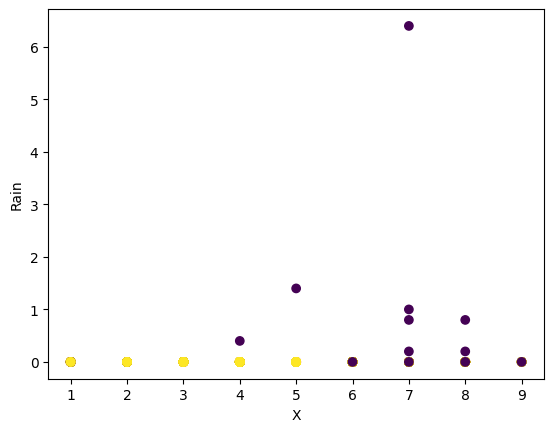

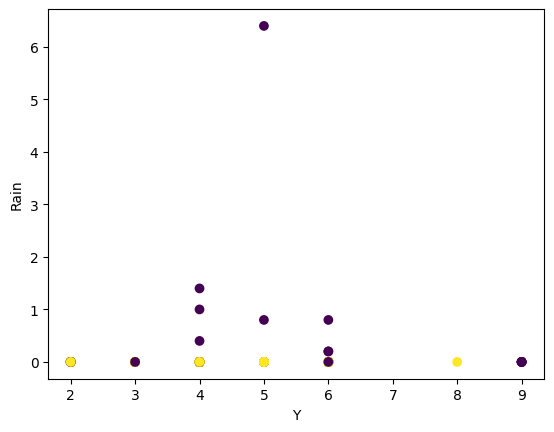

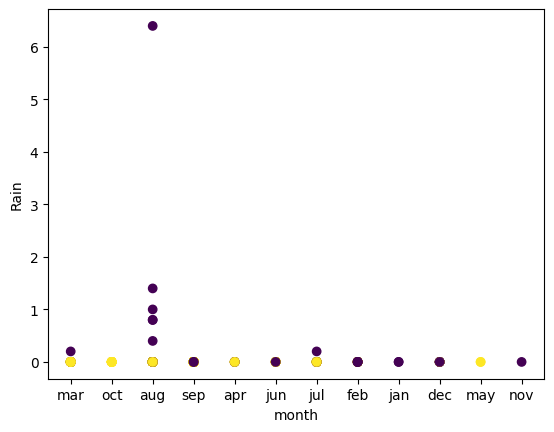

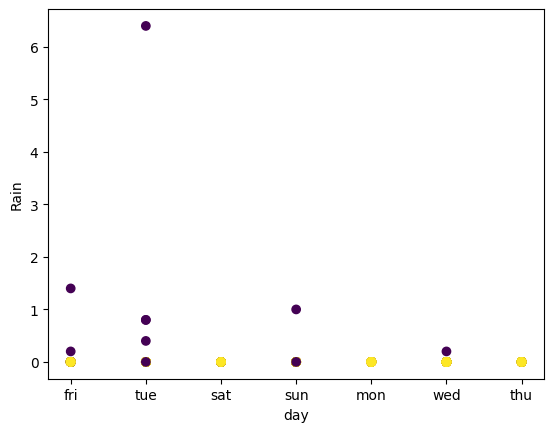

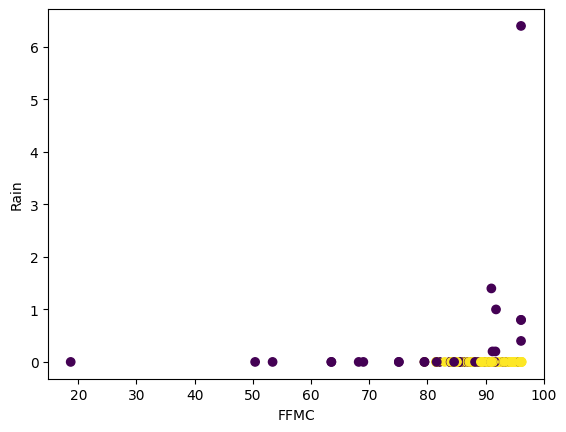

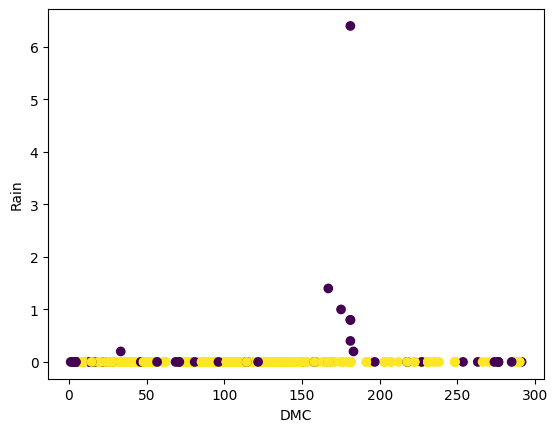

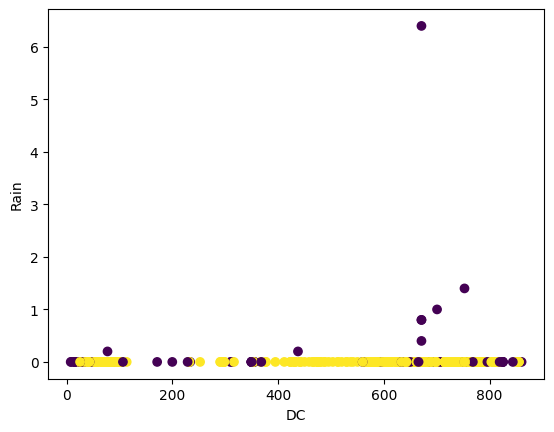

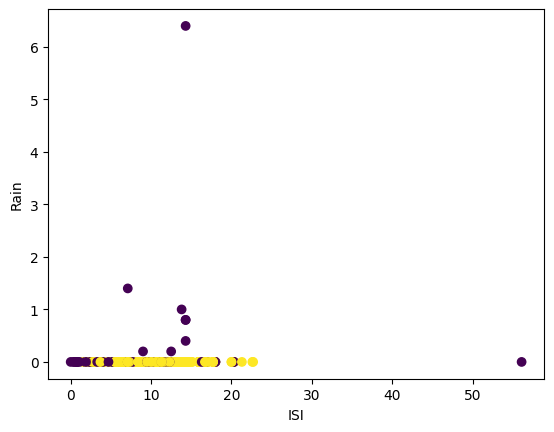

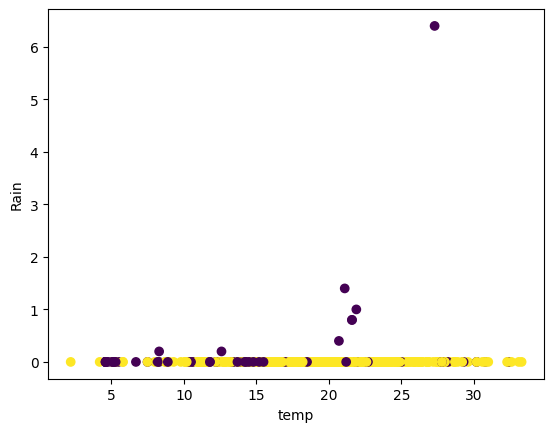

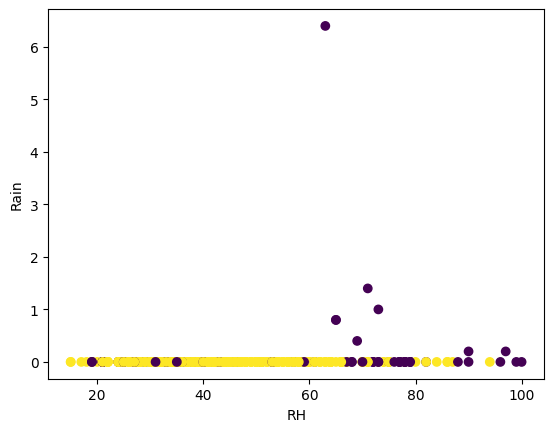

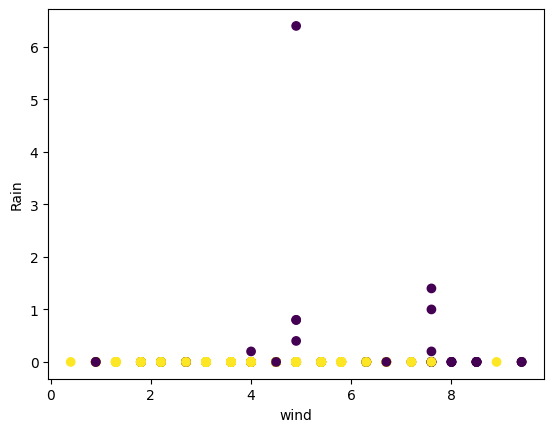

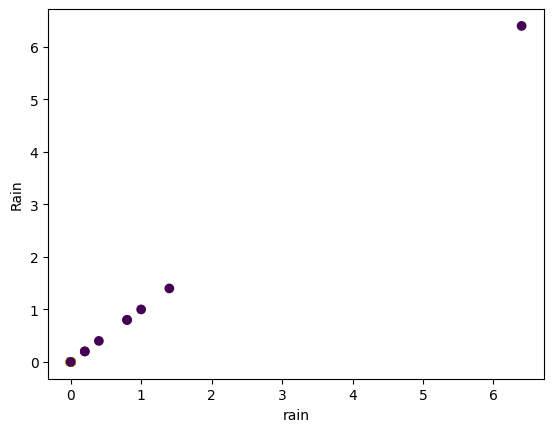

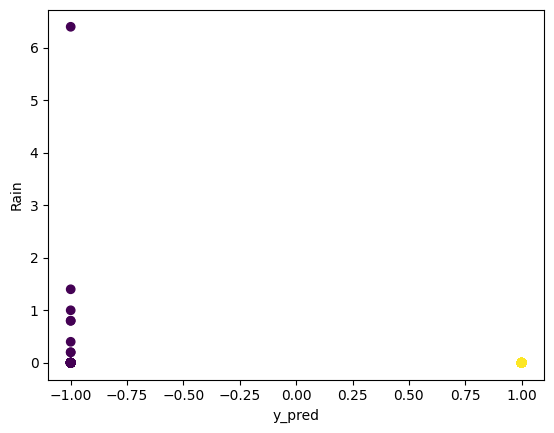

In [175]:
for col in X.columns:
  plt.scatter(X[col], X['rain'], c= y_pred)
  plt.xlabel(col)
  plt.ylabel('Rain')
  plt.show()